<a href="https://colab.research.google.com/github/MalaikaJunaid/Seevia/blob/main/Seevia_Semantic_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import random

# 1. Load your Universal Semantic Base
semantic_knowledge = {
    "Zone_Staples": {
        "brands": ["National", "Shan", "Mehran", "Guard", "Mughal"],
        "items": ["Masala", "Rice", "Chaawal", "Aata", "Sugar", "Cheeni", "Baisan"]
    },
    "Zone_Breakfast_Baking": {
        "brands": ["Tapal", "Lipton", "Nescafe", "Olpers", "Milkpak", "Rafhan"],
        "items": ["Tea", "Chai", "Coffee", "Milk", "Custard", "Jelly", "Cocoa Powder"]
    },
    "Zone_Personal_Care": {
        "brands": ["Colgate", "Sensodyne", "Sunsilk", "Pantene", "Lux", "Lifebuoy"],
        "items": ["Toothpaste", "Shampoo", "Soap", "Conditioner", "Handwash"]
    }
}

# 2. Template sentences to generate 1,200+ samples
templates = [
    "Where is [ITEM]?",
    "[BRAND] [ITEM] kahan hai?",
    "I need to buy [BRAND] [ITEM].",
    "[ITEM] kidher para hua hai?",
    "Show me the way to [BRAND].",
    "Mujhe [ITEM] chahiye."
]

augmented_data = []

# 3. Generate Data
for zone, data in semantic_knowledge.items():
    for _ in range(400):  # Generate 400 samples per zone
        brand = random.choice(data["brands"])
        item = random.choice(data["items"])
        template = random.choice(templates)

        # Replace placeholders
        query = template.replace("[BRAND]", brand).replace("[ITEM]", item)
        augmented_data.append({"text": query, "label": zone})

# 4. Save for training
df = pd.DataFrame(augmented_data)
df.to_csv("semantic_training_data.csv", index=False)
print(f"✅ Generated {len(df)} samples for Semantic Classification!")

✅ Generated 1200 samples for Semantic Classification!


In [7]:
from google.colab import userdata
from huggingface_hub import login

# Access your secret named HF_W_TOKEN
HF_TOKEN = userdata.get('HF_W_TOKEN')

if HF_TOKEN:
    login(HF_TOKEN)
    print("✅ Successfully logged in to Hugging Face!")
else:
    print("❌ Token 'HF_W_TOKEN' not found in Colab secrets. Please check the name.")

✅ Successfully logged in to Hugging Face!


In [9]:
!pip install --upgrade transformers
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset

# 1. Load Data
df = pd.read_csv("semantic_training_data.csv")
labels = sorted(df['label'].unique())
label2id = {label: i for i, label in enumerate(labels)}
id2label = {i: label for i, label in enumerate(labels)}
df['label'] = df['label'].map(label2id)

# 2. Tokenization
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-multilingual-cased")
def tokenize_func(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True)

dataset = Dataset.from_pandas(df).map(tokenize_func, batched=True)
dataset = dataset.train_test_split(test_size=0.2)

# 3. Model Setup
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-multilingual-cased",
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id
)

# 4. Updated Training Arguments for Transformers 5.2.0
training_args = TrainingArguments(
    output_dir="./seevia_semantic_model",
    eval_strategy="epoch",        # Changed from evaluation_strategy
    save_strategy="epoch",        # Must match eval_strategy
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    push_to_hub=False,            # Set to True if you want to upload to Hugging Face
    report_to="wandb",            # Continues syncing to your MalaikaJunaid account
    logging_steps=10,
    load_best_model_at_end=True   # Good practice for FYP results
)

# 5. Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
)

trainer.train()

Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,0.546295,0.348220


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=180, training_loss=0.348190918399228, metrics={'train_runtime': 10212.0241, 'train_samples_per_second': 0.282, 'train_steps_per_second': 0.018, 'total_flos': 381512911749120.0, 'train_loss': 0.348190918399228, 'epoch': 3.0})

In [10]:
# Zip the semantic model folder
!zip -r seevia_semantic_model.zip ./seevia_semantic_model

  adding: seevia_semantic_model/ (stored 0%)
  adding: seevia_semantic_model/checkpoint-60/ (stored 0%)
  adding: seevia_semantic_model/checkpoint-60/optimizer.pt (deflated 71%)
  adding: seevia_semantic_model/checkpoint-60/training_args.bin (deflated 53%)
  adding: seevia_semantic_model/checkpoint-60/rng_state.pth (deflated 26%)
  adding: seevia_semantic_model/checkpoint-60/config.json (deflated 52%)
  adding: seevia_semantic_model/checkpoint-60/trainer_state.json (deflated 66%)
  adding: seevia_semantic_model/checkpoint-60/scheduler.pt (deflated 61%)
  adding: seevia_semantic_model/checkpoint-60/model.safetensors (deflated 7%)
  adding: seevia_semantic_model/checkpoint-180/ (stored 0%)
  adding: seevia_semantic_model/checkpoint-180/optimizer.pt (deflated 71%)
  adding: seevia_semantic_model/checkpoint-180/training_args.bin (deflated 53%)
  adding: seevia_semantic_model/checkpoint-180/rng_state.pth (deflated 26%)
  adding: seevia_semantic_model/checkpoint-180/config.json (deflated 52%

In [11]:
from google.colab import files
# Download the zipped model to your computer
files.download('seevia_semantic_model.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


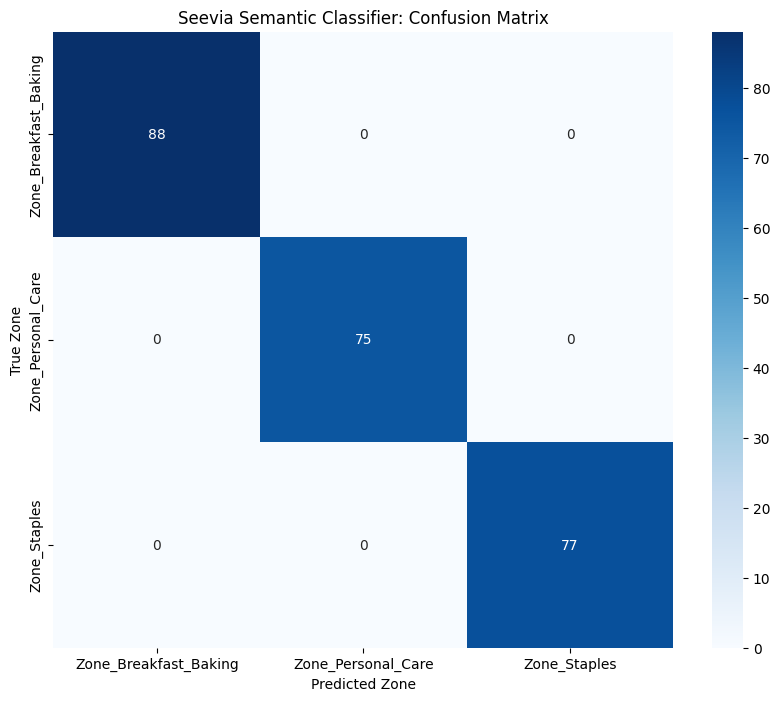

                       precision    recall  f1-score   support

Zone_Breakfast_Baking       1.00      1.00      1.00        88
   Zone_Personal_Care       1.00      1.00      1.00        75
         Zone_Staples       1.00      1.00      1.00        77

             accuracy                           1.00       240
            macro avg       1.00      1.00      1.00       240
         weighted avg       1.00      1.00      1.00       240



In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Get predictions from the test set
predictions = trainer.predict(dataset["test"])
y_pred = np.argmax(predictions.predictions, axis=-1)
y_true = predictions.label_ids

# 2. Generate Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Zone')
plt.ylabel('True Zone')
plt.title('Seevia Semantic Classifier: Confusion Matrix')
plt.show()

# 3. Print F1-Score Report
print(classification_report(y_true, y_pred, target_names=labels))

In [14]:
def predict_zone(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    outputs = model(**inputs)
    pred_id = outputs.logits.argmax().item()
    return id2label[pred_id]

# Test cases
print(f"Lipton: {predict_zone('Lipton chai kahan hai?')}")
print(f"Shan: {predict_zone('Mujhe Shan masala chahiye')}")
print(f"Surf: {predict_zone('Surf excel kidher para hai?')}")

Lipton: Zone_Breakfast_Baking
Shan: Zone_Staples
Surf: Zone_Personal_Care
